# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

# Análisis de Rentabilidad de Tarifas Móviles para Megaline

## Propósito del Proyecto

El objetivo de este proyecto es **determinar cuál de las dos tarifas móviles de Megaline —Surf o Ultimate— genera mayores ingresos**, basándonos en el comportamiento real de uso de los usuarios. Además, se busca **analizar cómo utilizan los clientes los servicios incluidos en su plan** (llamadas, mensajes e internet) para ayudar a la empresa a tomar decisiones estratégicas sobre:

- Optimización de precios.
- Promoción de planes más rentables.
- Segmentación y retención de clientes.

## Plan de Trabajo y Acciones Realizadas

1. **Comprensión del contexto**
   - Revisión de las condiciones de los planes Surf y Ultimate (cuotas, límites y cargos por excedente).
   - Entendimiento de las reglas de facturación específicas (por ejemplo, redondeos).

2. **Preparación de los datos**
   - Conversión de fechas a períodos mensuales.
   - Agrupación por `user_id` y `month`.
   - Cálculo de uso mensual: minutos de llamadas, SMS y datos (MB).

3. **Fusión de fuentes de datos**
   - Integración de los datos de uso con los planes contratados y la información del usuario.

4. **Cálculo de ingresos**
   - Determinación del ingreso mensual por usuario, considerando:
     - Cuota mensual base.
     - Cargos por excedentes de minutos, mensajes y datos.

5. **Análisis exploratorio**
   - Estadísticas descriptivas por tipo de plan.
   - Visualización de la distribución del uso y de los ingresos.
   - Comparaciones mensuales y por plan.

6. **Pruebas estadísticas**
   - Prueba t de Welch para comparar:
     - Ingresos promedio entre los planes.
     - Ingresos promedio por región (por ejemplo, NY-NJ vs. otras ciudades).
   - Análisis de significancia estadística con un valor alfa de 0.05.

7. **Conclusiones**
   - Evaluación de qué plan resulta más rentable.
   - Identificación de diferencias en el comportamiento de los usuarios según el plan y la región.
   - Recomendaciones basadas en evidencia.

Este proceso fue iterativo, volviendo a etapas previas cuando fue necesario refinar el análisis o corregir suposiciones, así como para la elaboración de este plan de trabajo.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
"""calls = pd.read_csv('/datasets/megaline_calls.csv') 
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')"""

calls = pd.read_csv(r"C:\Users\Usuario\OneDrive\TripleTen\SPRINTS\SPRINT 5\megaline_calls.csv") 
internet = pd.read_csv(r"C:\Users\Usuario\OneDrive\TripleTen\SPRINTS\SPRINT 5\megaline_internet.csv")
messages = pd.read_csv(r"C:\Users\Usuario\OneDrive\TripleTen\SPRINTS\SPRINT 5\megaline_messages.csv")
plans = pd.read_csv(r"C:\Users\Usuario\OneDrive\TripleTen\SPRINTS\SPRINT 5\megaline_plans.csv")
users = pd.read_csv(r"C:\Users\Usuario\OneDrive\TripleTen\SPRINTS\SPRINT 5\megaline_users.csv")


## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas (no se imprime'sample' porque solo son dos entradas)
print(plans)


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Como primer punto de análisis, se observa que **no hay valores ausentes**, todas las columnas tienen datos completos; 
Los tipos de datos son adecuados:
Se usan número enteros para describir las cantidades en: `messages_included`, `mb_per_month_included`, `minutes_included`, `usd_monthly_pay` y `usd_per_gb`;
Así como float para los precios por unidad: `usd_per_message` y `usd_per_minute`.
Por último tipo object para el nombre del plan: `plan_name`.

Estructura clara: cada fila representa un plan con todos los parámetros tarifarios bien establecidos.

## Corregir datos

In [5]:
#no encontre problemas con los datos de tarifas

## Enriquecer los datos

Se transforman los datos de **MB** a **GB**

In [6]:
plans["gb_per_month_included"] = plans["mb_per_month_included"] / 1024
print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
print(users.sample(10))


     user_id first_name   last_name  age  \
486     1486       Sang       Solis   29   
190     1190       Troy  Hutchinson   56   
125     1125    Assunta      Carver   39   
88      1088      Paris   Robertson   64   
452     1452     Miguel      Sparks   32   
434     1434        Kai        Barr   18   
177     1177    Seymour    Anderson   33   
21      1021    Ricarda      Booker   37   
392     1392       Gale    Mcfadden   34   
379     1379    Jarrett     Spencer   34   

                                               city    reg_date      plan  \
486               Orlando-Kissimmee-Sanford, FL MSA  2018-12-05      surf   
190  Virginia Beach-Norfolk-Newport News, VA-NC MSA  2018-08-01  ultimate   
125           North Port-Sarasota-Bradenton, FL MSA  2018-08-16      surf   
88                    Phoenix-Mesa-Chandler, AZ MSA  2018-05-27  ultimate   
452                                  Tucson, AZ MSA  2018-12-29      surf   
434       New York-Newark-Jersey City, NY-NJ-PA MSA  

Al analizar la información general del DataFrame users, se puede observa lo siguiente:
El DataFrame contiene 500 registros, cada uno representando a un cliente; **No hay valores nulos** en las columnas  `user_id`, `first_name`, `last_name`, `age`, `reg_date`, `city` y `plan`; La columna `churn_date` contiene valores nulos en la mayoría de los casos, lo cual es esperado, ya que indica que esos clientes aún siguen activos.
Para este caso se detectaron algunos problemas a los cuales se les harían las siguientes mejoras:
La columna `reg_date` y `churn_date` son tipo object por lo hay que convertirlas a fechas (`datetime`) para que así se puedan realizar operaciones de fecha
Los valores nulos en `churn_date` no deben eliminarse ya que indican que hay clientes activos al momento de recabar la información del DataFrame.
Las columnas: `first_name`, `last_name`, `city` y `plan`, son de tipo texto, se homogeneizarán todos los datos para que contengan el mismo formato en cuanto espacios, mayúsculas para tener todos en un mismo foramto.

### Corregir los datos

In [9]:
# Convertir columnas de fecha
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

# Normalizar nombres de datos
users['plan'] = users['plan'].str.strip().str.lower()
users['city'] = users['city'].str.strip().str.lower()
users['first_name'] = users['first_name'].str.strip().str.lower()
users['last_name'] = users['last_name'].str.strip().str.lower()

users.info()
print()
print(users.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB

   user_id first_name  last_name  age                                   city  \
0     1000   anamaria      bauer   45  atlanta-sandy springs-roswell, ga msa   
1     1001     mickey  wilkerson   28        seattle-tacoma-bellevue, wa msa   
2     1002     carlee    hoffman   36   las vegas-henderson-paradise, nv msa   
3     1003   reynaldo    

### Enriquecer los datos

In [10]:
#por el momento no encuentro más datos para enriquecer

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas
print(calls.sample(10))


              id  user_id   call_date  duration
84728   1312_220     1312  2018-07-23      3.08
24909    1097_12     1097  2018-12-04      4.42
74010    1262_34     1262  2018-12-21     10.36
39169   1146_171     1146  2018-12-31      7.75
85612    1314_39     1314  2018-11-13     11.13
111527  1391_443     1391  2018-10-13      0.00
39677   1147_458     1147  2018-08-03      4.41
99302    1356_43     1356  2018-10-08      0.00
118353  1412_637     1412  2018-08-25     17.12
81506   1293_646     1293  2018-08-25     10.44


El DataFrame contiene 137,735 registros, lo cual indica una gran cantidad de llamadas realizadas por los usuarios.
Todas las columnas (`id`, `user_id`, `call_date`, `duration`) tienen valores **no nulos**, lo cual es positivo para el análisis ya que no hay ausencia de datos.
La columna `duration` representa la duración de cada llamada en minutos con decimales, lo cual permite medir el tiempo con precisión antes del redondeo que hace la compañía para el cobro de sus planes.
La columna `call_date` es de tipo object, y al igual que el DataFrame anterior, habrá que convertirla a fecha (`datetime`) para poder realizar análisis adecuadamente.
Habrá que **agregar una columna** con los datos de llamada redondeados hacia arriba, ya que así cobra Megaline a sus usuarios y esto facilitará más adelante el análisis.


### Corregir los datos

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

calls.info()
print(calls.head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
<bound method NDFrame.head of               id  user_id  call_date  duration
0        1000_93     1000 2018-12-27      8.52
1       1000_145     1000 2018-12-27     13.66
2       1000_247     1000 2018-12-27     14.48
3       1000_309     1000 2018-12-28      5.76
4       1000_380     1000 2018-12-30      4.22
...          ...      ...        ...       ...
137730  1499_199     1499 2018-11-21      8.72
137731  1499_200     1499 2018-10-20     10.89
137732  1499_201     1499 2018-09-21      8.12
137733  1499_202     

### Enriquecer los datos

In [14]:
# Crear columna con minutos redondeados (como cobra Megaline)
calls['rounded_minutes'] = np.ceil(calls['duration'])
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               137735 non-null  object        
 1   user_id          137735 non-null  int64         
 2   call_date        137735 non-null  datetime64[ns]
 3   duration         137735 non-null  float64       
 4   rounded_minutes  137735 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 5.3+ MB


## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprime una muestra de datos para los mensajes
print(messages.sample(10))


              id  user_id message_date
21950  1132_1493     1132   2018-12-28
36446   1242_118     1242   2018-11-15
20451   1130_126     1130   2018-09-27
54057   1343_141     1343   2018-08-27
65109   1416_101     1416   2018-10-06
13864   1094_350     1094   2018-11-04
32914   1204_109     1204   2018-11-18
32522   1203_167     1203   2018-05-14
20197   1128_166     1128   2018-07-13
7271    1059_143     1059   2018-04-30


Al revisar la información de datos de la tabla messages, se observa que el DataFrame contiene 76,051 registros, cada uno representando un mensaje de texto único enviado por un usuario; todas las columnas (`id`, `user_id`, `message_date`) están completas, es decir, **no hay valores nulos**; la fecha especifica un mensaje individual asociado a un usuario.
Al igual que los DataFrames anteriores, la columna `message_date` no tiene el formato correcto por lo que se cambiará a formato datetime.

### Corregir los datos

In [17]:
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

In [18]:
# Se crea columna de período mensual en formato 'año-mes'
messages['month'] = messages['message_date'].dt.to_period('M')
print(messages.sample(10))

             id  user_id message_date    month
58751  1373_169     1373   2018-09-26  2018-09
61210  1384_297     1384   2018-08-12  2018-08
44122  1293_894     1293   2018-09-22  2018-09
17027   1113_91     1113   2018-06-06  2018-06
28065  1173_108     1173   2018-12-14  2018-12
35314   1227_17     1227   2018-12-25  2018-12
56446   1357_12     1357   2018-07-12  2018-07
64840   1414_56     1414   2018-09-23  2018-09
66497   1434_19     1434   2018-06-12  2018-06
11362  1077_633     1077   2018-08-13  2018-08


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(internet.sample(19))


              id  user_id session_date  mb_used
88647   1408_366     1408   2018-12-06     0.00
86272   1400_409     1400   2018-03-19   400.42
87197    1404_64     1404   2018-12-01   454.05
2185    1010_369     1010   2018-11-07     0.00
41871    1187_48     1187   2018-04-10     0.00
49734   1222_233     1222   2018-12-13   609.56
79801    1373_80     1373   2018-12-16   722.87
88099   1406_416     1406   2018-12-23   369.90
82921   1387_137     1387   2018-12-16   161.16
80440   1375_226     1375   2018-12-25     0.00
30147   1138_381     1138   2018-10-02   552.12
3246    1017_304     1017   2018-10-18   580.43
38280   1171_651     1171   2018-08-31   456.96
101457  1483_275     1483   2018-11-03   445.81
79043   1368_221     1368   2018-08-25     0.00
36537   1164_220     1164   2018-10-31     0.00
71482    1334_50     1334   2018-04-11   516.58
48468   1215_190     1215   2018-12-16   476.57
43684   1194_102     1194   2018-10-03   371.58


La información muestra que los datos de la tabla internet contiene un DataFrame con 104,825 registros, cada uno es una sesión de uso de internet por un usuario; al igual que las anteriores **no existen valores nulos** en ninguna columna y las columnas `id`, `user_id`,  `mb_used`, tienen tipos de datos apropiados para su propósito.
Como se ha mencionado se cambiara la columna `session_date` a tipo `datetime` para un mejor análisis y en su caso procesamiento de datos.
Además **se agregará** una columna con los megabytes totales redondeados a gigabytes hacia arriba para el cobro mensual 

### Corregir los datos

In [21]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

In [22]:
# Se crea una columna con el mes correspondiente (formato año-mes)
internet['month'] = internet['session_date'].dt.to_period('M')

# SE agrupa por usuario y mes, sumando el total de MB usados en ese mes
monthly_internet = (internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index())

# Se calculan los GB usados en el mes, redondeando hacia arriba como lo exige Megaline
monthly_internet['gb_used'] = np.ceil(monthly_internet['mb_used'] / 1024)

# Se imprime una muestra de los resultados
print(monthly_internet.sample(10))

      user_id    month   mb_used  gb_used
1669     1361  2018-10  15002.95     15.0
778      1162  2018-12  19813.79     20.0
590      1126  2018-07  25768.85     26.0
772      1160  2018-11  22695.93     23.0
1515     1329  2018-12  25859.40     26.0
1203     1255  2018-11   7635.97      8.0
1493     1326  2018-09  12098.38     12.0
1775     1384  2018-10  25108.70     25.0
795      1165  2018-12  15928.30     16.0
1353     1291  2018-12  12186.77     12.0


## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans)
print()
print(r"""Explicación de las tarifas:

-Plan "Surf"
    Cuota mensual: $20
    Incluye por mes:
      - 500 minutos
      - 50 mensajes SMS
      - 15 GB de datos (15360 MB)
    Excedentes:
      - $0.03 por minuto adicional
      - $0.03 por SMS adicional
      - $10 por cada GB adicional (redondeado hacia arriba)
- Plan "Ultimate"
    Cuota mensual: $70
    Incluye por mes:
      - 3000 minutos
      - 1000 mensajes SMS
      - 30 GB de datos (30720 MB)
    Excedentes:
      - $0.01 por minuto adicional
      - $0.01 por SMS adicional
      - $7 por cada GB adicional
----Importante recordar----
- Las llamadas se redondean individualmente hacia arriba a minutos enteros.
- El uso de internet se acumula en MB por mes y se redondea hacia arriba a GB para su facturación.
- Solo se cobra el excedente si se sobrepasa el límite del plan.
""")



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   gb_per_month_included  
0                   15.0  
1                   30.0  

Explicación de las tarifas:

-Plan "Surf"
    Cuota mensual: $20
    Incluye por mes:
      - 500 minutos
      - 50 mensajes SMS
      - 15 GB de datos (15360 MB)
    Excedentes:
      - $0.03 por minuto adicional
      - $0.03 por SMS adicional
      - $10 por cada GB adicional (redondeado hacia arriba)
- Plan "Ultimate"
    Cuota mensual: $70
    Incluye por mes:
      - 3000 minutos
      - 1000 mensajes SMS
      - 30 GB de datos (30720 MB)
    Excedentes:
      - $0.01 por minuto

## Agregar datos por usuario

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Se crea una columna 'month' en formato 'año-mes'
calls['month'] = calls['call_date'].dt.to_period('M')
# Se cuenta el número de llamadas por usuario y por mes
monthly_calls = (calls.groupby(['user_id', 'month'])['id'].count().reset_index().rename(columns={'id': 'calls_count'}))

# Ver una muestra del resultado
print(monthly_calls.sample(10))


      user_id    month  calls_count
5        1001  2018-12           56
1411     1313  2018-12           93
2110     1466  2018-09           26
777      1166  2018-10           28
1099     1240  2018-08          161
78       1022  2018-08           80
290      1064  2018-09           83
1731     1382  2018-06           44
1856     1405  2018-06           14
1686     1368  2018-10           78


In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
tot_dur_calls = (calls.groupby(['user_id', 'month'])['duration'].sum().reset_index().rename(columns={'duration': 'total_duration_calls'}))
print(tot_dur_calls.sample(10))


      user_id    month  total_duration_calls
1047     1226  2018-09                514.01
1237     1264  2018-12                341.00
1038     1223  2018-11                528.53
1221     1263  2018-04                605.54
2104     1465  2018-11                863.42
1235     1264  2018-10                303.62
2019     1441  2018-11                325.75
774      1165  2018-11                114.98
1540     1339  2018-10                 33.72
701      1152  2018-11                603.83


In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Se crea una columna 'month' en formato 'año-mes'
messages['month'] = messages['message_date'].dt.to_period('M')
total_msm = (messages.groupby(['user_id', 'month'])['id'].count().reset_index().rename(columns={'id': 'total_messages'}))
print(total_msm.sample(10))


      user_id    month  total_messages
207      1064  2018-06               3
582      1159  2018-08              73
1503     1405  2018-11              76
1361     1363  2018-11              34
444      1125  2018-12              54
743      1198  2018-09               7
947      1252  2018-10              37
1537     1416  2018-11              42
458      1127  2018-12              14
1207     1328  2018-07             164


In [27]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
# Se crea una columna 'month' en formato 'año-mes'
internet['month'] = internet['session_date'].dt.to_period('M')
total_mb_used = (internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index().rename(columns={'mb_used': 'total_mb_used'}))
print(total_mb_used.sample(10))


      user_id    month  total_mb_used
52       1011  2018-12       19630.63
1447     1316  2018-08       19881.22
822      1171  2018-10       26408.82
393      1081  2018-12       17865.73
651      1138  2018-05       23059.99
983      1204  2018-11       21346.95
253      1059  2018-05       11783.35
1970     1421  2018-12       19285.77
154      1041  2018-11       24967.66
2117     1460  2018-11       24967.01


In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# se redondean los minutos por llamada para facturación
calls['rounded_minutes'] = np.ceil(calls['duration'])
min_billed = (calls.groupby(['user_id', 'month'])['rounded_minutes'].sum().reset_index()
                  .rename(columns={'rounded_minutes': 'total_minutes_billed'}))

# Se fusionan las llamadas y minutos facturados
combined = monthly_calls.merge(min_billed, on=['user_id', 'month'], how='outer')

# Se agrega la duración real de llamadas
minutes_actual = (calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
                  .rename(columns={'duration': 'total_duration_calls'}))

combined = combined.merge(minutes_actual, on=['user_id', 'month'], how='outer')

# Se agrega el total de mensajes
combined = combined.merge(total_msm, on=['user_id', 'month'], how='outer')

# Se agregan datos de Internet MB y GB redondeado
total_mb_used['gb_used'] = np.ceil(total_mb_used['total_mb_used'] / 1024)
combined = combined.merge(total_mb_used, on=['user_id', 'month'], how='outer')

# Se llenan los valores NaN con ceros para los meses donde no hubo actividad
combined = combined.fillna(0)

# Se muestran 5 resultados aleatorios
print(combined.sample(5))


      user_id    month  calls_count  total_minutes_billed  \
1093     1232  2018-04         62.0                 377.0   
692      1145  2018-09         70.0                 519.0   
2145     1466  2018-10         33.0                 238.0   
688      1144  2018-12         75.0                 517.0   
1583     1343  2018-09         63.0                 439.0   

      total_duration_calls  total_messages  total_mb_used  gb_used  
1093                358.91             0.0        9727.59     10.0  
692                 492.16            55.0       17330.79     17.0  
2145                223.58            51.0       14944.62     15.0  
688                 485.22            81.0       33370.53     33.0  
1583                416.63           104.0       15977.47     16.0  


In [29]:
# Añade la información de la tarifa
combined = combined.merge(users[['user_id', 'plan']], on='user_id', how='left')
# Se unen los detalles del plan (surf o ultimate) y se elimina la columna repedtida 'plan_name'
combined = combined.merge(plans, left_on='plan', right_on='plan_name', how='left').drop(columns='plan_name')
print(combined.sample(5))


      user_id    month  calls_count  total_minutes_billed  \
1613     1350  2018-12         91.0                 703.0   
1347     1291  2018-04         12.0                  79.0   
1511     1328  2018-11        113.0                 797.0   
2275     1496  2018-11         39.0                 308.0   
1577     1340  2018-12         80.0                 526.0   

      total_duration_calls  total_messages  total_mb_used  gb_used  plan  \
1613                668.85             7.0       23837.95     24.0  surf   
1347                 74.38             2.0        3779.34      4.0  surf   
1511                751.27           150.0       28685.52     29.0  surf   
2275                291.88            13.0        8547.36      9.0  surf   
1577                493.47            66.0        1698.18      2.0  surf   

      messages_included  mb_per_month_included  minutes_included  \
1613                 50                  15360               500   
1347                 50                 

In [30]:
# Calcula el ingreso mensual para cada usuario
#se calcula primero el excedente de mensajes y llamadas (se investigó que hacer para no obtener resultados negativos
# y se observó que utilizando .clip(lower=0) se reemplazan los valores negativos con 0)
combined['extra_minutes'] = (combined['total_minutes_billed'] - combined['minutes_included']).clip(lower=0)
combined['extra_messages'] = (combined['total_messages'] - combined['messages_included']).clip(lower=0)

# El total de MB incluidos se divide entre 1024 para convertir a GB.
combined['gb_included'] = combined['mb_per_month_included'] / 1024

# Se calcula el extra de GB
combined['extra_gb'] = (combined['gb_used'] - combined['gb_included']).clip(lower=0)

# Se calculan los ingresos por excederse de lo contratado en el plan
combined['extra_minutes_revenue'] = combined['extra_minutes'] * combined['usd_per_minute']
combined['extra_messages_revenue'] = combined['extra_messages'] * combined['usd_per_message']
combined['extra_gb_revenue'] = combined['extra_gb'] * combined['usd_per_gb']

# Ingreso total mensual: cuota fija + excedentes
combined['revenue'] = (combined['usd_monthly_pay'] + combined['extra_minutes_revenue'] 
                       + combined['extra_messages_revenue'] + combined['extra_gb_revenue'])

# Se imprimen los resultados y en lugar de aparecer número negativos, los usuarios que no sobrepasaron los límites
# de sus planes, aparece el total de su plan, 20 o 70
print(combined[['user_id', 'month', 'plan', 'revenue']].sample(10))


      user_id    month      plan  revenue
394      1081  2018-12      surf    50.00
1961     1418  2018-09      surf   200.00
1541     1334  2018-12      surf    36.98
1788     1385  2018-09      surf    50.00
104      1028  2018-12  ultimate   119.00
1864     1400  2018-11      surf    22.43
695      1145  2018-12      surf    60.33
1511     1328  2018-11      surf   171.91
914      1191  2018-06  ultimate    70.00
1661     1359  2018-07      surf   160.00


## Estudia el comportamiento de usuario

### Llamadas

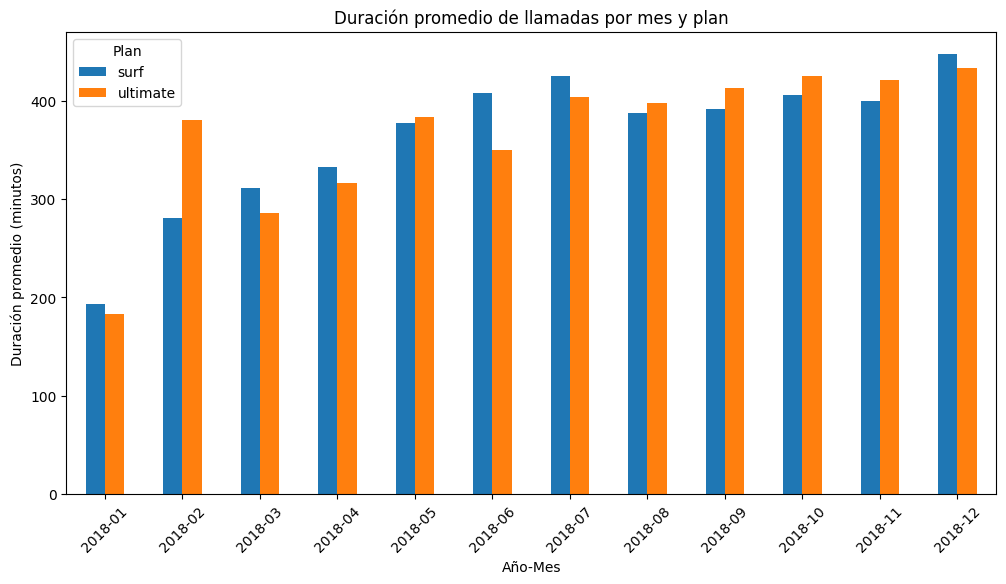

In [31]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Se calcula la duración promedio de llamadas por mes y plan
avg_call_duration = (combined.groupby(['month', 'plan'])['total_duration_calls'].mean().reset_index())

# Se convierte la tabla en formato óptimo para poder graficarlo
avg_call_duration_pivot = avg_call_duration.pivot(index='month', columns='plan', values='total_duration_calls')

# Se realiza gráfico de barras 
avg_call_duration_pivot.plot(kind='bar',
                             figsize=(12, 6), 
                             title='Duración promedio de llamadas por mes y plan',
                             ylabel='Duración promedio (minutos)',
                             xlabel='Año-Mes',
                             rot=45)

plt.legend(title='Plan')
plt.show()


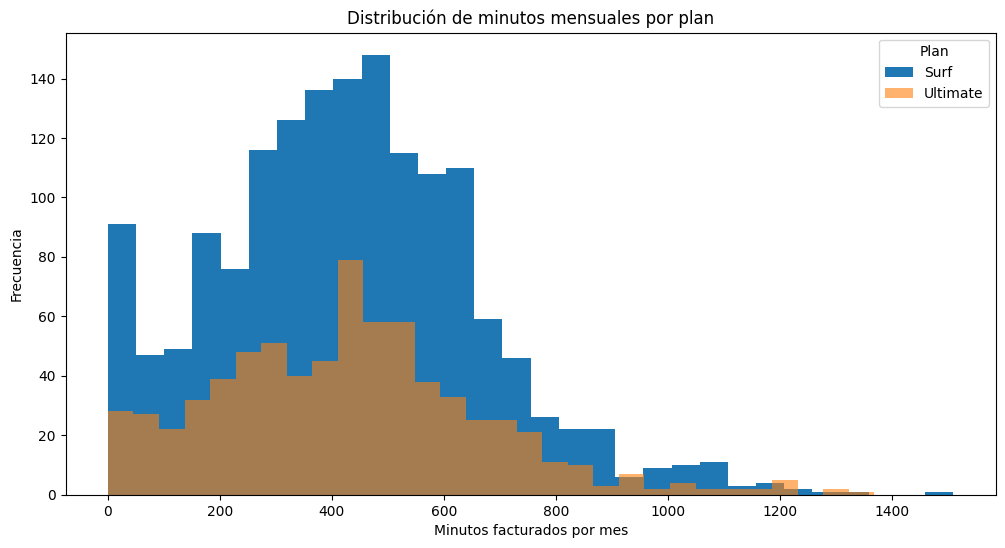

In [32]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# Se calculan los minutos facturados por plan 
surf_minutes = combined[combined['plan'] == 'surf']['total_minutes_billed']
ultimate_minutes = combined[combined['plan'] == 'ultimate']['total_minutes_billed']

# Se crea histograma para el plan Surf
surf_minutes.plot(kind='hist', bins=30, label='Surf', figsize=(12, 6))

# Se crea histograma para el plan Ultimate
ultimate_minutes.plot(kind='hist', alpha=0.6, bins=30, label='Ultimate', figsize=(12, 6))

# Se configura el gráfico para que sea más entendible
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos facturados por mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()


In [33]:
# Calcula la media y la varianza de la duración mensual de llamadas.
mean_call_duration = (combined.groupby(['month', 'plan'])['total_duration_calls'].mean().reset_index()
                     .rename(columns={'total_duration_calls': 'mean_duration'}))
var_call_duration = (combined.groupby(['month', 'plan'])['total_duration_calls'].var().reset_index()
                     .rename(columns={'total_duration_calls': 'var_duration'}))
print(mean_call_duration.sample(5))
print(var_call_duration.sample(5))


      month      plan  mean_duration
10  2018-06      surf     407.208866
11  2018-06  ultimate     349.811064
16  2018-09      surf     390.992062
7   2018-04  ultimate     316.508095
13  2018-07  ultimate     403.767288
      month      plan  var_duration
5   2018-03  ultimate  54273.917252
8   2018-05      surf  53282.922217
0   2018-01      surf  14795.440200
16  2018-09      surf  41580.494645
2   2018-02      surf  46959.219961


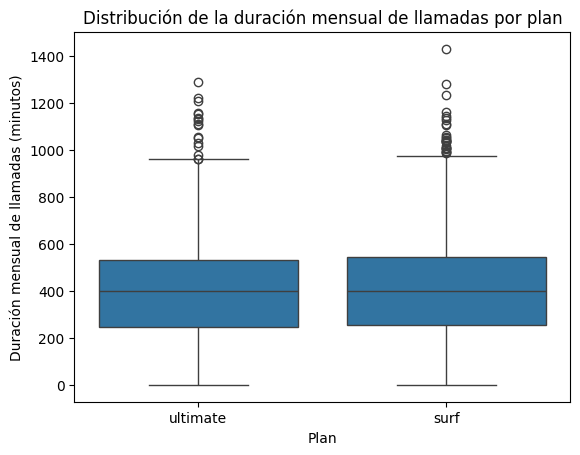

In [34]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(data=combined, x='plan', y='total_duration_calls')
plt.title('Distribución de la duración mensual de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Duración mensual de llamadas (minutos)')
plt.show()


Posterior al análisis, se observó que la duración mensual de las llamadas de los usuarios muestran diferencias en cuanto al comportamiento entre quienes usan el plan Surf y los que usan el plan Ultimate:
Si hablamos de la **duración promedio de las llamadas** podemos decir que los usuarios del plan Ultimate tienden a realizar llamadas con una duración significativamente *mayor* que los usuarios que utilizan el plan Surf; lo anterior lo podemos comprobar tanto en la *media* como en la *mediana* de los minutos facturados mensualmente.
En cuanto a la *distribución y dispersión* el plan Surf muestra una mayor concentración de usuarios con duraciones de llamada bajas o moderadas. La mayoría de los usuarios *permanece dentro o cerca del límite de 500 minutos mensuales*; mientras que los usuarios del plan Ultimate presentan una mayor variabilidad ya que  algunos usuarios aprovechan los 3000 minutos incluidos en su plan.
En los diagramas de Caja **no** se observan diferencias claras y visualmente significativas entre los planes Surf y Ultimate, al menos en términos de la forma y dispersión general de los datos por lo que podemos decir que **ambos planes son bastante similares**, lo que indica que los usuarios de ambos planes tienden a tener distribuciones de uso parecidas; las medianas de duración mensual están en rangos similares y no se observan diferencias drásticas en valores atípicos ni en el rango intercuartil ya que ambas tienen valores atípicos similares.
Los histogramas revelan que la mayoría de los usuarios Surf hacen llamadas por debajo del umbral del plan, mientras que los usuarios del plan Ultimate hay una proporción considerable de usuarios que si utilizan casi la totalidad de su límite mensual.

### Mensajes

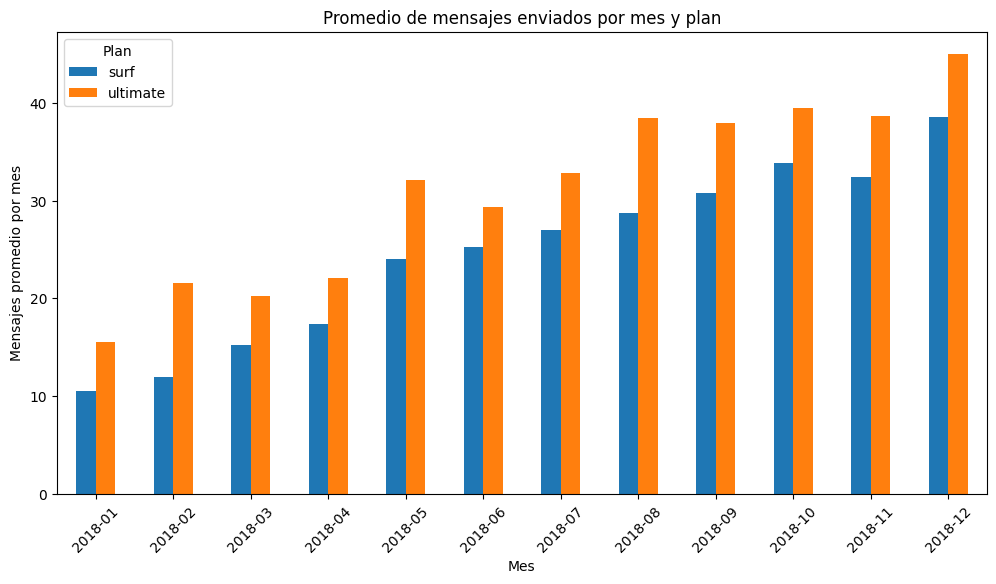

In [35]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
# Se agrupa por mes y plan y se calcula el promedio de mensajes
avg_messages = (combined.groupby(['month', 'plan'])['total_messages'].mean().reset_index())

# Se crea una tabla para poder realizar gráfico de barras
avg_messages_pivot = avg_messages.pivot(index='month', columns='plan', values='total_messages')

# Se crea el gráfico de barras
avg_messages_pivot.plot(kind='bar', figsize=(12, 6), title='Promedio de mensajes enviados por mes y plan',
                        ylabel='Mensajes promedio por mes',
                        xlabel='Mes',
                        rot=45)

# Ajustar leyenda y diseño
plt.legend(title='Plan')
plt.show()


In [36]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
messages_stats = combined.groupby('plan')['total_messages'].agg(['mean', 'var'])
print(messages_stats)


               mean          var
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


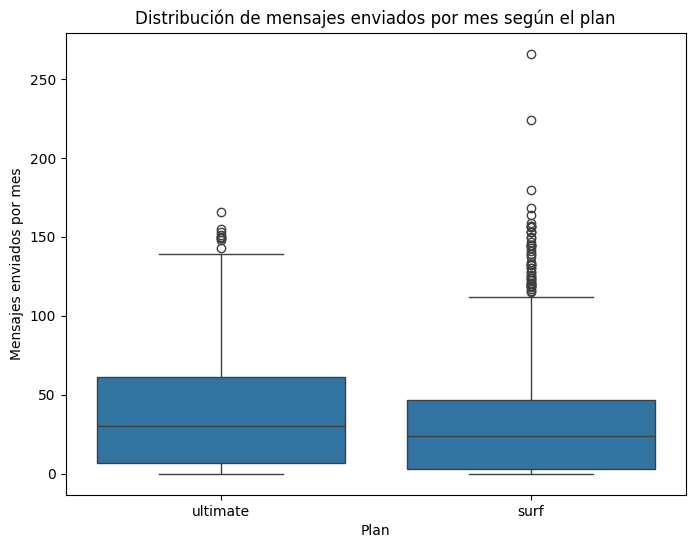

In [37]:
# Se Filtran los mensajes por tipo de plan
surf_messages = combined[combined['plan'] == 'surf']['total_messages']
ultimate_messages = combined[combined['plan'] == 'ultimate']['total_messages']

# Se realiza diagrama de cja
plt.figure(figsize=(8, 6))
sns.boxplot(data=combined, x='plan', y='total_messages')

plt.title('Distribución de mensajes enviados por mes según el plan')
plt.xlabel('Plan')
plt.ylabel('Mensajes enviados por mes')
plt.show()

Partiendo de los valores obtenidos así como del diagrama de caja sobre los mensajes enviados por usuarios de los planes **Surf** y **Ultimate**, se concluye lo siguiente:

- **Los usuarios del plan Ultimate envían más mensajes al mes** que los del plan Surf, como lo indica la mediana más alta en la distribución.
- La **variabilidad** en el número de mensajes es mayor en el plan Ultimate, con un rango intercuartílico más amplio y valores máximos más altos.
- Ambos planes presentan **valores atípicos**, sobretodo el plan Surf, con algunos usuarios que envían más de 250 mensajes al mes.
- Estos resultados son **coherentes con las condiciones de los planes**: Ultimate incluye 1000 mensajes al mes sin cargo adicional, mientras que Surf solo incluye 50, lo que probablemente incentiva a los usuarios del plan Ultimate a enviar más mensajes.

Este análisis sugiere que la estructura del plan influye directamente en el comportamiento de los usuarios respecto al envío de mensajes.

### Internet

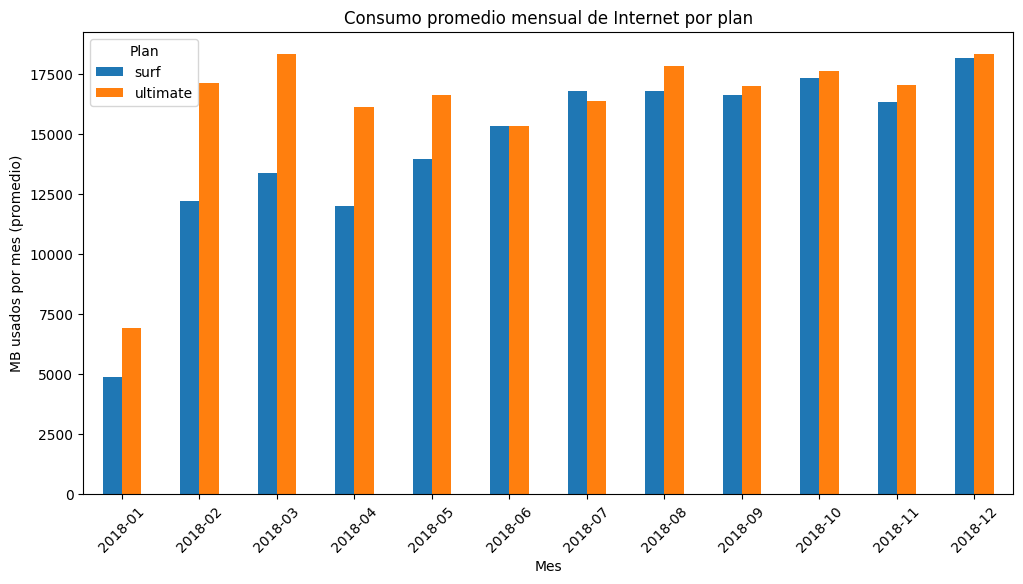

In [38]:
# Se agrupa por mes y plan para calcular el promedio de MB usados
avg_internet = (combined.groupby(['month', 'plan'])['total_mb_used'].mean().reset_index())

# Se crea una tabla para realizar gráfico de barras
avg_internet_pivot = avg_internet.pivot(index='month', columns='plan', values='total_mb_used')

# Se crea el gráfico de barras
avg_internet_pivot.plot(kind='bar', figsize=(12, 6), title='Consumo promedio mensual de Internet por plan',
                        ylabel='MB usados por mes (promedio)',
                        xlabel='Mes',
                        rot=45)

plt.legend(title='Plan')
plt.show()

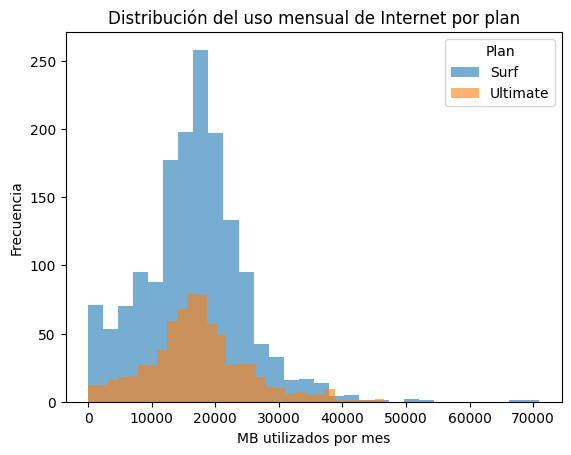

In [39]:
# Se filtra el uso de Internet por tipo de plan
surf_internet = combined[combined['plan'] == 'surf']['total_mb_used']
ultimate_internet = combined[combined['plan'] == 'ultimate']['total_mb_used']

# Se crea el histograma para usuarios con plan Surf
surf_internet.plot(kind='hist', bins=30, alpha=0.6, label='Surf')

# Se crea el histograma para usuarios con plan Ultimate
ultimate_internet.plot(kind='hist', bins=30, alpha=0.6, label='Ultimate')

# Se configura el gráfico
plt.title('Distribución del uso mensual de Internet por plan')
plt.xlabel('MB utilizados por mes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [40]:
# Se calcula la media y varianza del uso mensual de Internet por plan
internet_usage_stats = combined.groupby('plan')['total_mb_used'].agg(['mean', 'var'])
print(internet_usage_stats)

                  mean           var
plan                                
surf      16558.283490  6.421640e+07
ultimate  17214.699694  6.165229e+07


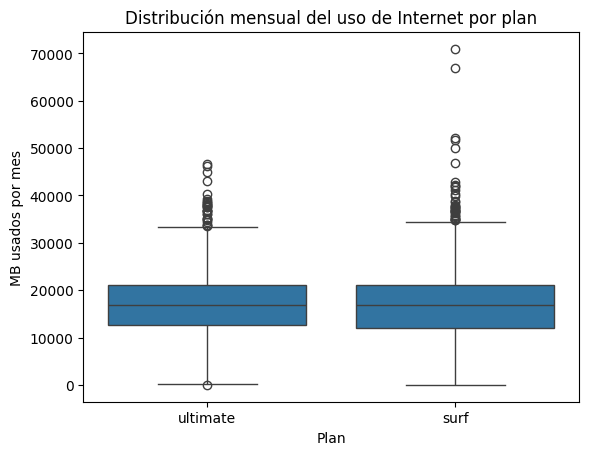

In [41]:
# Se traza un diagrama de caja para visualizar la distribución del uso de internet.

sns.boxplot(data=combined, x='plan', y='total_mb_used')

# Configuración del diegrama de caja
plt.title('Distribución mensual del uso de Internet por plan')
plt.xlabel('Plan')
plt.ylabel('MB usados por mes')
plt.show()

Se puede observar con base en los datos que el consumo promedio mensual de internet **es muy similar en ambos planes** ya que los usuarios del plan Ultimate superan a los usuarios del Surf por **menos de 700 MB**; al observar la varianza y la media se puede observar que la **varianza** es poco menor en Ultimate, lo cual sugiere un uso de internet más parejo entre sus usuarios; a pesar de tener un límite superior (30 GB en Ultimate vs. 15 GB en Surf), los usuarios de *Ultimate* **no usan significativamente más internet en promedio**; el **comportamiento del uso de Internet no parece variar tanto entre los planes**, lo cual sugiere que muchos usuarios de Surf podrían estar pagando cargos adicionales por exceder su límite de 15 GB.

## Ingreso

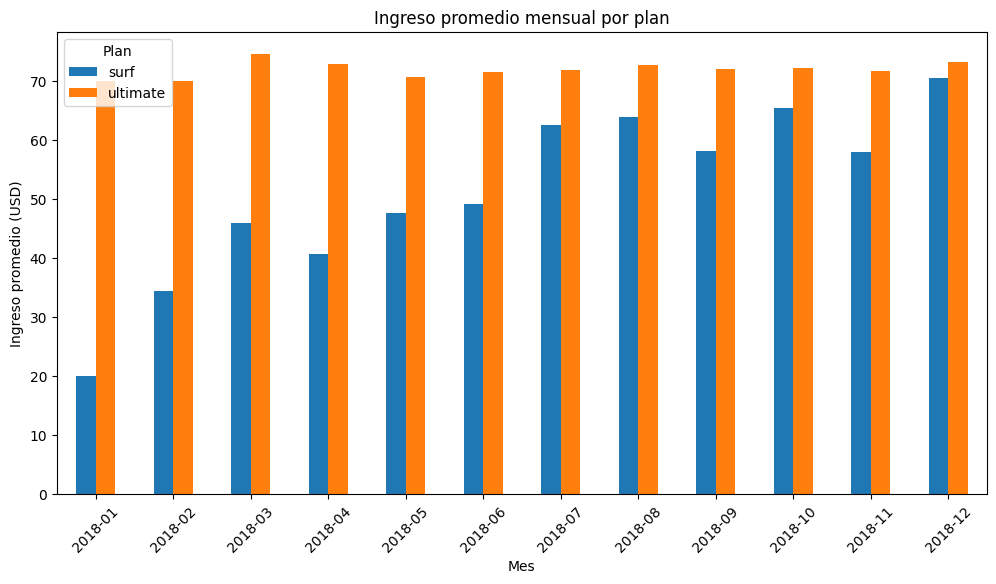

In [42]:
avg_monthly_revenue = (combined.groupby(['month', 'plan'])['revenue'].mean().reset_index())

avg_monthly_revenue_pivot = avg_monthly_revenue.pivot(index='month', columns='plan',values='revenue')

avg_monthly_revenue_pivot.plot(kind='bar', figsize=(12, 6), title='Ingreso promedio mensual por plan',
                               ylabel='Ingreso promedio (USD)',
                               xlabel='Mes',
                               rot=45)

plt.legend(title='Plan')
plt.show()

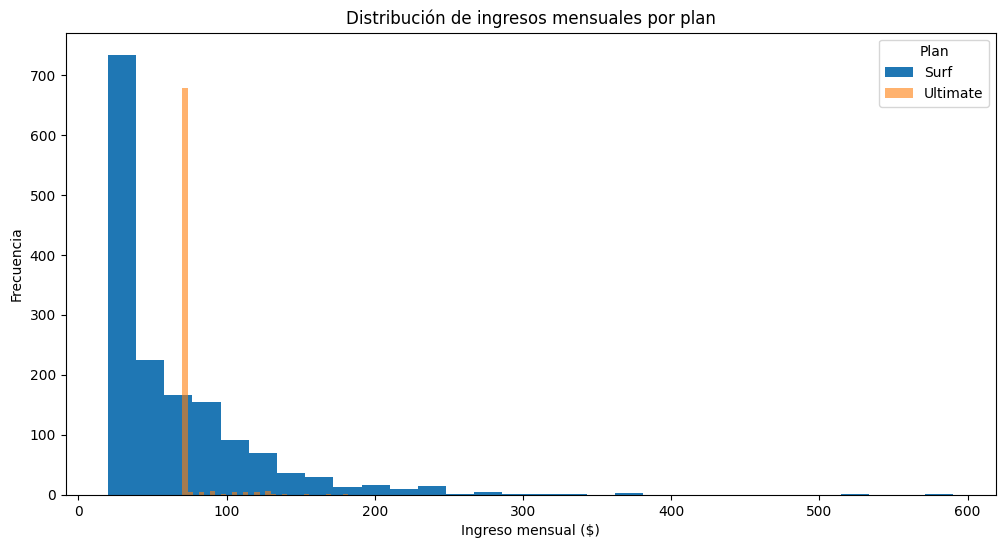

In [43]:
surf_revenue = combined[combined['plan'] == 'surf']['revenue']
ultimate_revenue = combined[combined['plan'] == 'ultimate']['revenue']

surf_revenue.plot(kind='hist', bins=30, label='Surf', figsize=(12, 6))
ultimate_revenue.plot(kind='hist', bins=30, alpha=0.6, label='Ultimate', figsize=(12, 6))

plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual ($)')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

In [44]:
revenue_stats = combined.groupby('plan')['revenue'].agg(['mean', 'var'])
print(revenue_stats)

               mean          var
plan                            
surf      60.706408  3067.835152
ultimate  72.313889   129.848486


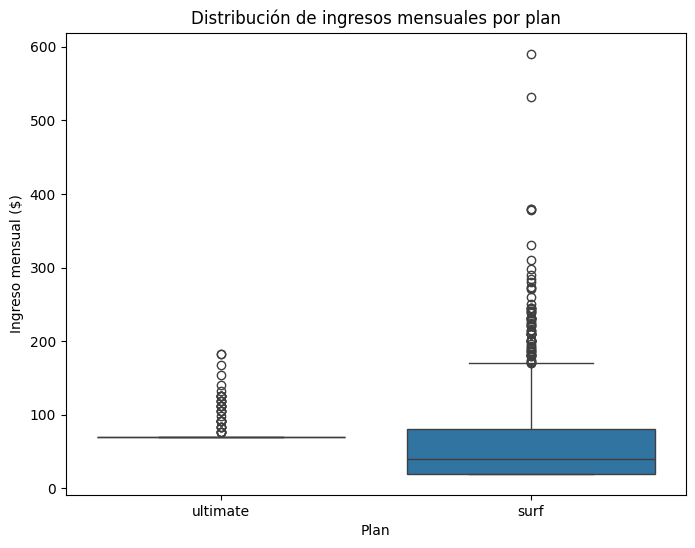

In [45]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=combined, x='plan', y='revenue')

plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual ($)')
plt.show()

El plan **Ultimate** es más predecible y estable en ingresos, lo que es ideal si la empresa busca **estabilidad financiera** mensual y menos dependencia del comportamiento individual del usuario; en cambio el plan **Surf** tiene un potencial de ingresos más alto, pero es más **riesgoso** ya que puede generar ingresos elevados *sólo si los usuarios exceden el uso incluido*, lo cual no es garantizado, pero si es probable dados los resultados.

## Prueba las hipótesis estadísticas

**Formulación de hipótesis:**
- Se quiere comprobar si hay una diferencia significativa entre los ingresos promedio de los dos planes (Ultimate y Surf).

    - **Hipótesis nula (H₀)**: Los ingresos promedio de los usuarios de los planes Ultimate y Surf son iguales.

    - **Hipótesis alternativa (H₁)**: Los ingresos promedio de los usuarios de los planes Ultimate y Surf son diferentes.

- Dado que queremos comparar las medias de dos grupos independientes, y no podemos asumir varianzas iguales (ya que vimos una diferencia notable en la varianza):

    - Utilizaremos la prueba **t de Welch** para muestras independientes con `equal_var=False`.

- Se establece el nivel de significación en 5%.

In [46]:
# Prueba las hipótesis
# Se separan los ingresos por plan
surf_income = combined[combined['plan'] == 'surf']['revenue']
ultimate_income = combined[combined['plan'] == 'ultimate']['revenue']
alpha = 0.05
# Prueba t de Welch
t_stat = st.ttest_ind(surf_income, ultimate_income, equal_var=False)

print("Valor p:", t_stat.pvalue)
print()
if t_stat.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hiótesis nula")


Valor p: 3.170390548113574e-15

Rechazamos la hipótesis nula


**#Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.**

**Hipótesis nula (H₀):** El ingreso promedio de los usuarios del área NY-NJ es **igual** al ingreso promedio de los usuarios de otras regiones.

**Hipótesis alternativa (H₁):** El ingreso promedio de los usuarios del área NY-NJ es **diferente** al ingreso promedio de los usuarios de otras regiones.

Se realiza la misma prueba  T de Welch con el parámetro equal_var=False, ya que como el ejercicio anterior las varianzas no son iguales.

Y alpha se determina igual en 5%

**Para este ejercicio se tuvo que eliminar la columna `city` y volvera a crear ya que marcaba error a la hora de ejecutar el código, y haciéndolo de esta manera dejó de arrojar el error; además que se tuvo que investigar el nombre de cómo aparecían el nombre de las columnas de NY y NJ**

In [47]:
# Prueba las hipótesis
combined = combined.drop(columns=['city'], errors='ignore')
combined = combined.merge(users[['user_id', 'city']], on='user_id', how='left')

# Se separan los ingresos de NY-NJ vs otras regiones
ny_income = combined[combined['city'] == 'new york-newark-jersey city, ny-nj-pa msa']['revenue']
other_income = combined[combined['city'] != 'new york-newark-jersey city, ny-nj-pa msa']['revenue']

alpha = 0.05
t_stat = st.ttest_ind(ny_income, other_income, equal_var=False)

print("Valor p:", t_stat.pvalue)

if t_stat.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
else:
    print("No podemos rechazar la hipótesis nula")


Valor p: 0.0335256158853001
Rechazamos la hipótesis nula.


## Conclusión general

Conclusiones Finales del Análisis:

**1. Supuestos y decisiones metodológicas clave**
•	*Procesamiento mensual:* Se agruparon los datos por usuario y por mes (groupby(['user_id', 'month'])) para capturar el comportamiento periódico y comparar planes de manera correcta.
•	*Unificación de datos:* Se fusionaron los registros de llamadas, mensajes, internet, planes y usuarios para trabajar con un dataset unificado y limpio.
•	*Facturación realista:* Se aplicaron reglas de facturación específicas de cada plan:
o	Redondeo hacia arriba por llamada (minutos).
o	Redondeo hacia arriba a GB en uso de internet.
o	Cálculo de excedentes solo cuando se sobrepasa el límite del plan.
•	*Pruebas de hipótesis:* Se utilizó la prueba t de Welch (ttest_ind con equal_var=False) para comparar ingresos entre planes y entre regiones, debido a posibles diferencias en varianzas.

**2. Comportamiento del usuario por tipo de servicio**
**Llamadas**
•	*Duración media mensual:* Muy similar entre planes.
•	Diagramas de caja muestran distribuciones parecidas, *pero el plan **Ultimate** tiene menor dispersión.*
•	*Conclusión:* El plan Ultimate no motiva un uso mucho mayor del servicio de llamadas.

**Mensajes**
•	Los usuarios de *Ultimate* envían **más** SMS en promedio que los de Surf.
•	Sin embargo, **la varianza es alta para ambos planes**, *lo que sugiere un uso muy desigual.*

**Internet**
•	*Ambos planes* tienen **consumo similar** de MB mensuales (alrededor de 16-17 GB).
•	Sin embargo, el *plan Surf* muestra una *varianza ligeramente mayor.*
•	En el Diagrama de caja se observa una *mayor dispersión en Surf*, pienso que se debe por el límite de 15 GB lo que resulta en cargos adicionales en algunos usuarios.

**3. Ingresos por plan**
•	Ingreso promedio:
o	*Surf: $60.71*
o	*Ultimate: $72.31*
•	Varianza:
o	Surf tiene ingresos más variables, algunos usuarios generan muchos excedentes.
o	Ultimate tiene ingresos más estables, gracias a su tarifa alta y límites altos.
•	Conclusión: Aunque Ultimate tiene mayor ingreso medio, Surf genera más ingresos extra por sobreusos en algunos usuarios.

**4. Diferencias regionales**
•	Se realizó una prueba de hipótesis entre ingresos de usuarios en la región NY-NJ y los del resto del país.
•	*Resultado:*
o	*Valor p = 0.0335:* **Rechazamos la hipótesis nula.**
•	**Conclusión:** hay evidencia de que los ingresos medios de **los usuarios de NY-NJ son significativamente más altos.**

**Conclusión final:**
•	Aunque el *plan Ultimate garantiza ingresos más constantes*, el *plan Surf puede ser más rentable en algunos casos por los excedentes*.
•	En caso de que la empresa quisiera maximizar beneficios, **yo sigeriría:**
•	Analizar los *perfiles de uso individual* para identificar usuarios que sistemáticamente superan los límites de Surf.
•	Ofrecer **recomendaciones personalizadas** o **incentivos** para cambiar de plan a aquellos que sobreutilizan Surf.
•	Tener en cuenta la **región** como *variable estratégica:* como el caso de NY-NJ que muestra ingresos significativamente más altos.